In [2]:
import pandas as pd

df = pd.read_csv("/content/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# Check missing values
print(df.isnull().sum())

# Fill numeric missing values with median
df = df.fillna(df.median(numeric_only=True))

# Encode categorical columns (if any)
df = pd.get_dummies(df, drop_first=True)

df.head()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,150.0,2.3,0.0,0,True,False,...,False,True,True,False,False,False,False,False,False,False
1,2,67,160.0,286.0,108.0,1.5,3.0,2,True,False,...,False,False,False,False,False,True,True,False,True,False
2,3,67,120.0,229.0,129.0,2.6,2.0,1,True,False,...,False,False,False,False,False,True,True,False,False,True
3,4,37,130.0,250.0,187.0,3.5,0.0,0,True,False,...,True,False,False,True,False,False,False,False,True,False
4,5,41,130.0,204.0,172.0,1.4,0.0,0,False,False,...,False,False,False,False,False,False,False,True,True,False


In [5]:
# Change target column name if needed
y = df["num"]   # If error, check column name using df.columns
X = df.drop("num", axis=1)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

k_values = [3, 5, 7, 11, 15]

results = {}
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[k] = (acc, prec, rec, f1)
    f1_scores.append(f1)

    print(f"---- k = {k} ----")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print()

---- k = 3 ----
Accuracy : 0.5217391304347826
Precision: 0.4648880676142484
Recall   : 0.5217391304347826
F1 Score : 0.4843954287503416

---- k = 5 ----
Accuracy : 0.532608695652174
Precision: 0.48826758531489406
Recall   : 0.532608695652174
F1 Score : 0.5060527287120297

---- k = 7 ----
Accuracy : 0.5489130434782609
Precision: 0.5086800802848636
Recall   : 0.5489130434782609
F1 Score : 0.5235698821237574

---- k = 11 ----
Accuracy : 0.5652173913043478
Precision: 0.5258235122365559
Recall   : 0.5652173913043478
F1 Score : 0.5398709185487238

---- k = 15 ----
Accuracy : 0.5597826086956522
Precision: 0.5121052272938564
Recall   : 0.5597826086956522
F1 Score : 0.529732406775547



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import pandas as pd

results_df = pd.DataFrame(results,
                          index=["Accuracy", "Precision", "Recall", "F1-score"]).T

results_df

,Accuracy,Precision,Recall,F1-score
3,0.521739,0.464888,0.521739,0.484395
5,0.532609,0.488268,0.532609,0.506053
7,0.548913,0.508680,0.548913,0.523570
11,0.565217,0.525824,0.565217,0.539871
15,0.559783,0.512105,0.559783,0.529732


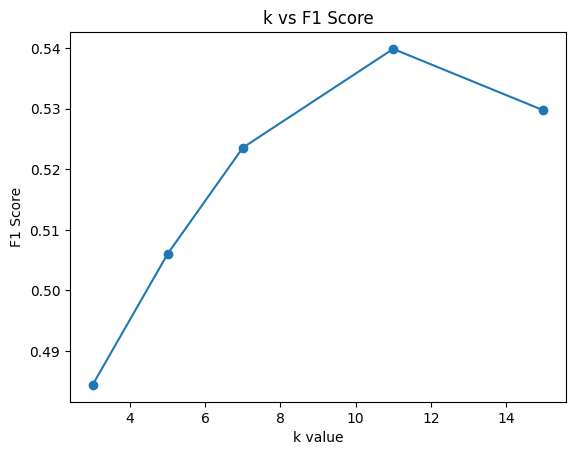

In [10]:
import matplotlib.pyplot as plt

plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("F1 Score")
plt.title("k vs F1 Score")
plt.show()

KNN classifier was trained with k = 3, 5, 7, 11, 15.
Lower k values may lead to overfitting (high variance).
Higher k values may lead to underfitting (high bias).
The best k is the one giving highest F1-score.
From the graph, the optimal k is: (write the best k from output).